# Fase 5: Evaluasi Model & Inference Interaktif

**Notebook ke-5** dari pipeline pelatihan model deteksi tulisan AI.

Di notebook ini, kita akan mengevaluasi performa model yang telah dilatih (`best_model.keras`)
menggunakan data uji (`test_data.npz`), lalu menjalankan antarmuka inference interaktif.

| Checkpoint | File | Keterangan |
|---|---|---|
| Input | `best_model.keras` | Model klasifikasi (Keras) |
| Input | `test_data.npz` | Data uji (dengan structural features yang sudah di-scale) |
| Input | `structural_scaler.pkl` | StandardScaler yang di-fit saat training |
| Input | `inference_config.json` | Optimal threshold & konfigurasi inference |

> **Catatan Arsitektur:**
> - Structural features HARUS di-transform dengan `structural_scaler.pkl` sebelum diprediksi.
> - Embedding HARUS di-L2-normalize (`normalize_embeddings=True` di SentenceTransformer).
> - Optimal threshold diambil dari `inference_config.json` (bukan default 0.5).


In [17]:
import sys
import subprocess
import os

# Aktifkan memory growth SEBELUM import tensorflow
# agar TF tidak memblokir seluruh VRAM (PyTorch MiniLM butuh sebagian)
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

required = ["pandas", "numpy", "matplotlib", "seaborn", "tensorflow", "scikit-learn", "ipywidgets"]
for pkg in required:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Memasang {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import tensorflow as tf

physical_devices = tf.config.list_physical_devices("GPU")
if physical_devices:
    try:
        for dev in physical_devices:
            tf.config.experimental.set_memory_growth(dev, True)
        print(f"Memory Growth diaktifkan untuk {len(physical_devices)} GPU.")
    except RuntimeError as e:
        print("⚠Gagal mengatur Memory Growth:", e)
else:
    print("Tidak mendeteksi GPU TensorFlow. Berjalan di CPU.")
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

print(f"TensorFlow: {tf.__version__}")


Memasang scikit-learn...
Memory Growth diaktifkan untuk 1 GPU.
TensorFlow: 2.21.0


## 1. Load Semua Artifact Training

Memuat semua artifact yang dihasilkan oleh Notebook 4:
- Model Keras
- StandardScaler (WAJIB untuk transformasi fitur saat inference)
- Test data
- Inference config (threshold optimal)


In [18]:
import numpy as np
import pickle
import json
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# Cek semua artifact
# -------------------------------------------------------
REQUIRED_FILES = {
    "best_model.keras"      : "Model Keras",
    "structural_scaler.pkl" : "StandardScaler (wajib untuk inference!)",
    "test_data.npz"         : "Test data",
    "inference_config.json" : "Konfigurasi threshold & inference",
}

print("=" * 60)
print("  MEMUAT ARTIFACT")
print("=" * 60)

missing = []
for fname, desc in REQUIRED_FILES.items():
    exists = os.path.exists(fname)
    status = "[OK] " if exists else "[MISS]"
    size   = f"{os.path.getsize(fname)/1024**2:.2f} MB" if exists else "—"
    print(f"  {status} {fname:<35} ({size})")
    if not exists:
        missing.append(fname)

if missing:
    print()
    print("Ada file yang hilang:", missing)
    print("   Pastikan Notebook 4 sudah dijalankan sampai selesai.")
else:
    # Load model
    print("\nMemuat model Keras...")
    model = tf.keras.models.load_model("best_model.keras")
    print(f"  Model input shapes : {[inp.shape for inp in model.inputs]}")

    # Load scaler
    print("Memuat StandardScaler...")
    with open("structural_scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    print(f"  Scaler features    : {scaler.n_features_in_}")
    print(f"  Scaler mean (3)    : {scaler.mean_[:3].round(4)}")

    # Load inference config (threshold)
    print("Memuat inference_config.json...")
    with open("inference_config.json") as f:
        inference_cfg = json.load(f)
    optimal_threshold = inference_cfg["optimal_threshold"]
    print(f"  Optimal threshold  : {optimal_threshold:.4f}")
    print(f"  Val ROC-AUC        : {inference_cfg.get('val_roc_auc', 'N/A')}")

    # Load test data
    print("Memuat test_data.npz...")
    with np.load("test_data.npz", allow_pickle=True) as data:
        X_test_struct = data["X_test_struct"]
        X_test_embed  = data["X_test_embed"]
        y_test        = data["y_test"]
        if "feature_cols" in data:
            active_features = list(data["feature_cols"])
        else:
            with open("feature_config.json") as f:
                active_features = json.load(f).get("active_features", [])

    print(f"  X_test_struct      : {X_test_struct.shape} (sudah di-scale)")
    print(f"  X_test_embed       : {X_test_embed.shape}")
    print(f"  y_test             : {y_test.shape}")
    print(f"  Human/AI           : {(y_test==0).sum()} / {(y_test==1).sum()}")

    print()
    print("=" * 60)
    print("  Semua artifact berhasil dimuat.")
    print("=" * 60)


  MEMUAT ARTIFACT
  [OK]  best_model.keras                    (0.62 MB)
  [OK]  structural_scaler.pkl               (0.00 MB)
  [OK]  test_data.npz                       (11.73 MB)
  [OK]  inference_config.json               (0.00 MB)

Memuat model Keras...
  Model input shapes : [(None, 23), (None, 384)]
Memuat StandardScaler...
  Scaler features    : 23
  Scaler mean (3)    : [14.066  25.8698 10.4286]
Memuat inference_config.json...
  Optimal threshold  : 0.7237
  Val ROC-AUC        : 0.9999825954437256
Memuat test_data.npz...
  X_test_struct      : (7515, 23) (sudah di-scale)
  X_test_embed       : (7515, 384)
  y_test             : (7515,)
  Human/AI           : 3662 / 3853

  Semua artifact berhasil dimuat.


## 2. Evaluasi Performa pada Test Set

Prediksi probabilitas pada test set, hitung ROC-AUC, cari threshold optimal
dengan Youden's J Statistic, dan tampilkan confusion matrix.

> Test set sudah menggunakan **group-based split** — tidak ada data leakage.
> Akurasi yang realistis (bukan 99%) adalah tanda model yang sehat.


Menjalankan prediksi pada test set...
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

  HASIL EVALUASI MODEL
  Test ROC-AUC       : 1.0000
  Threshold (val set): 0.7237  digunakan untuk prediksi
  Threshold (test opt): 0.8624 untuk referensi
  Accuracy           : 0.9984

--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00      3662
      AI (1)       1.00      1.00      1.00      3853

    accuracy                           1.00      7515
   macro avg       1.00      1.00      1.00      7515
weighted avg       1.00      1.00      1.00      7515



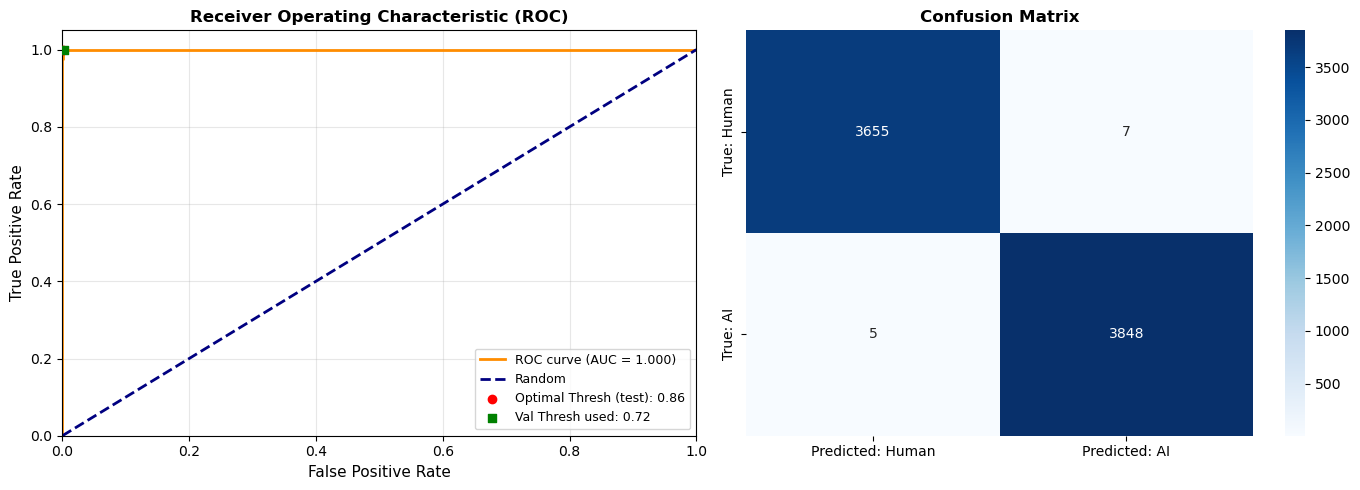

Plot disimpan ke: evaluation_results.png


In [19]:
# -------------------------------------------------------
# Prediksi pada test set (structural sudah di-scale dari NB4)
# -------------------------------------------------------
print("Menjalankan prediksi pada test set...")
y_pred_probs = model.predict([X_test_struct, X_test_embed], batch_size=256, verbose=1).ravel()

# Hitung ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Threshold dari inference_config (dihitung pada val set di NB4)
# Kita tampilkan juga threshold optimal dari test set untuk perbandingan
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_probs)
optimal_idx_test  = np.argmax(tpr - fpr)
threshold_on_test = float(thresholds_roc[optimal_idx_test])

# Gunakan threshold dari val set (seperti akan digunakan saat deployment)
y_pred = (y_pred_probs >= optimal_threshold).astype(int)

print()
print("=" * 65)
print("  HASIL EVALUASI MODEL")
print("=" * 65)
print(f"  Test ROC-AUC       : {roc_auc:.4f}")
print(f"  Threshold (val set): {optimal_threshold:.4f}  digunakan untuk prediksi")
print(f"  Threshold (test opt): {threshold_on_test:.4f} untuk referensi")
print(f"  Accuracy           : {accuracy_score(y_test, y_pred):.4f}")
print()
print("--- Laporan Klasifikasi ---")
print(classification_report(y_test, y_pred, target_names=["Human (0)", "AI (1)"]))
print("=" * 65)

# -------------------------------------------------------
# Plot ROC Curve + Confusion Matrix
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color="darkorange", lw=2,
             label=f"ROC curve (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
axes[0].scatter(
    [fpr[optimal_idx_test]], [tpr[optimal_idx_test]],
    marker="o", color="red", zorder=5,
    label=f"Optimal Thresh (test): {threshold_on_test:.2f}"
)
axes[0].scatter(
    [fpr[np.argmin(np.abs(thresholds_roc - optimal_threshold))]],
    [tpr[np.argmin(np.abs(thresholds_roc - optimal_threshold))]],
    marker="s", color="green", zorder=5,
    label=f"Val Thresh used: {optimal_threshold:.2f}"
)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("Receiver Operating Characteristic (ROC)", fontsize=12, fontweight="bold")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
    xticklabels=["Predicted: Human", "Predicted: AI"],
    yticklabels=["True: Human", "True: AI"]
)
axes[1].set_title("Confusion Matrix", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=130, bbox_inches="tight")
plt.show()
print("Plot disimpan ke: evaluation_results.png")


## 3. Error Analysis

Melihat *False Positives* (teks manusia yang diprediksi sebagai AI)
dan *False Negatives* (teks AI yang lolos sebagai manusia)
dengan tingkat kepercayaan kesalahan paling ekstrem.


Total kesalahan prediksi : 12 dari 7,515 (0.16%)
False Positives (Human AI) : 7
False Negatives (AI Human) : 5

Distribusi probabilitas AI pada test set:


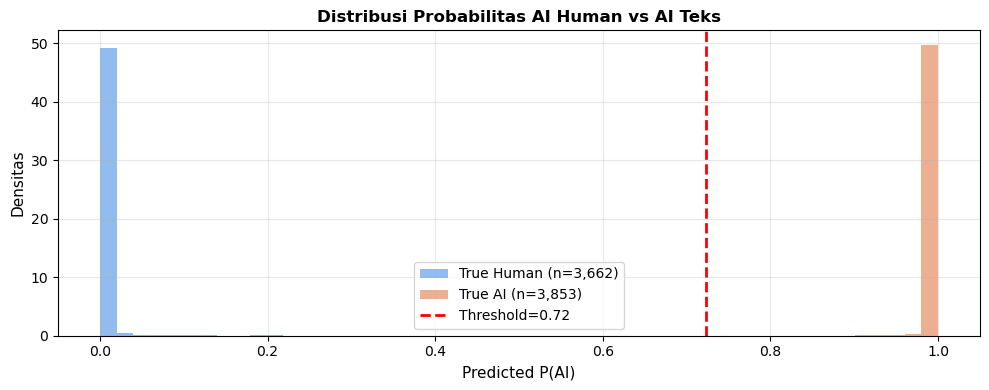

Plot disimpan ke: prob_distribution.png

Top 5 Kesalahan Paling Ekstrem:
  #1 | Sebenarnya: Human  | Ditebak: AI     | P(AI): 99.4%
         Top 5 fitur struktural (scaled): certainty_opener=24.53, sentence_count=4.61, unique_word_ratio=-1.53, comma_density=1.51, paragraph_length_std=1.46
  #2 | Sebenarnya: AI     | Ditebak: Human  | P(AI): 0.7%
         Top 5 fitur struktural (scaled): avg_word_length=-1.28, capital_ratio=0.81, comma_density=0.70, formal_tone_score=-0.58, transition_density=-0.57
  #3 | Sebenarnya: Human  | Ditebak: AI     | P(AI): 96.3%
         Top 5 fitur struktural (scaled): transition_density=1.14, formulaic_score=-0.74, comma_density=0.66, unique_word_ratio=0.65, avg_word_length=0.65
  #4 | Sebenarnya: Human  | Ditebak: AI     | P(AI): 86.2%
         Top 5 fitur struktural (scaled): not_only_but_also=1.90, capital_ratio=1.38, transition_density=-1.28, comma_density=1.15, avg_word_length=-0.94
  #5 | Sebenarnya: Human  | Ditebak: AI     | P(AI): 81.2%
         To

In [20]:
# -------------------------------------------------------
# Error Analysis
# -------------------------------------------------------
errors_idx     = np.where(y_test != y_pred)[0]
error_margins  = np.abs(y_pred_probs[errors_idx] - 0.5)  # jarak dari midpoint
sorted_err_idx = errors_idx[np.argsort(error_margins)[::-1]]

fp_count = int(((y_test[errors_idx] == 0) & (y_pred[errors_idx] == 1)).sum())
fn_count = int(((y_test[errors_idx] == 1) & (y_pred[errors_idx] == 0)).sum())

print(f"Total kesalahan prediksi : {len(errors_idx):,} dari {len(y_test):,} ({len(errors_idx)/len(y_test)*100:.2f}%)")
print(f"False Positives (Human AI) : {fp_count}")
print(f"False Negatives (AI Human) : {fn_count}")
print()

# Tampilkan distribusi probabilitas
print("Distribusi probabilitas AI pada test set:")
prob_human = y_pred_probs[y_test == 0]
prob_ai    = y_pred_probs[y_test == 1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(prob_human, bins=50, alpha=0.6, color="#4a90e2", label=f"True Human (n={len(prob_human):,})", density=True)
ax.hist(prob_ai,    bins=50, alpha=0.6, color="#e27a4a", label=f"True AI (n={len(prob_ai):,})",    density=True)
ax.axvline(optimal_threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold={optimal_threshold:.2f}")
ax.set_xlabel("Predicted P(AI)", fontsize=11)
ax.set_ylabel("Densitas", fontsize=11)
ax.set_title("Distribusi Probabilitas AI Human vs AI Teks", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("prob_distribution.png", dpi=130, bbox_inches="tight")
plt.show()
print("Plot disimpan ke: prob_distribution.png")

print("\nTop 5 Kesalahan Paling Ekstrem:")
for i in range(min(5, len(sorted_err_idx))):
    idx      = sorted_err_idx[i]
    true_lbl = "AI" if y_test[idx] == 1 else "Human"
    pred_lbl = "AI" if y_pred[idx] == 1 else "Human"
    prob_ai  = y_pred_probs[idx]
    print(f"  #{i+1} | Sebenarnya: {true_lbl:<6} | Ditebak: {pred_lbl:<6} | P(AI): {prob_ai*100:.1f}%")
    if active_features and len(active_features) <= X_test_struct.shape[1]:
        vals = X_test_struct[idx]  # (sudah di-scaled)
        # Fitur terbesar dalam ruang yang sudah di-scale
        top5 = np.argsort(np.abs(vals))[::-1][:5]
        print(f"         Top 5 fitur struktural (scaled): " +
              ", ".join(f"{active_features[j]}={vals[j]:.2f}" for j in top5 if j < len(active_features)))


## 4. Inference Interaktif

Masukkan teks bebas (Bahasa Indonesia atau Inggris) untuk dideteksi.

**Arsitektur inference:**
1. Teks `clean_text()` `detect_language()`
2. Teks bersih `extract_features()` 29 fitur raw
3. 29 fitur raw **`StandardScaler.transform()`** fitur ternormalisasi
4. Teks bersih **`SentenceTransformer.encode(normalize_embeddings=True)`** 384-dim L2-normalized
5. [fitur normalized, embedding] `model.predict()` `P(AI)`
6. `P(AI) >= optimal_threshold` "AI Generated" atau "Human Written"

> **Catatan:** Subprocess PyTorch digunakan agar TensorFlow dan PyTorch tidak saling mengalokasikan VRAM.


In [21]:
import ipywidgets as widgets
from IPython.display import display, HTML
import subprocess
import json
import sys
import numpy as np
import os

# -------------------------------------------------------
# Generate skrip subprocess untuk ekstraksi fitur + embedding
# (Terpisah dari kernel utama agar TF dan PyTorch tidak crash saling berebut VRAM)
# -------------------------------------------------------
extract_script = """
import sys
import json
import os
import numpy as np
import pickle

# Jangan import TensorFlow di subprocess ini
# Hanya PyTorch (via sentence-transformers) yang boleh jalan di sini

if __name__ == '__main__':
    text = sys.stdin.read()
    lang_arg = sys.argv[1] if len(sys.argv) > 1 else 'auto'
    force_lang = lang_arg if lang_arg in ('en', 'id') else None

    print("[Subprocess] Mengimpor library...", file=sys.stderr)
    from detector_pipeline import DetectorPipeline

    print("[Subprocess] Inisialisasi DetectorPipeline (memuat MiniLM)...", file=sys.stderr)
    pipeline = DetectorPipeline(use_gpu=True)

    print("[Subprocess] Memproses teks...", file=sys.stderr)
    res = pipeline.process_text(text, force_lang=force_lang)

    # Simpan raw struct array (SEBELUM di-scale) dan embed array (sudah L2-normalized)
    np.savez(
        'temp_inference.npz',
        x_struct_raw = res['x_struct'],   # shape (1, 29) raw, belum di-scale
        x_embed      = res['x_embed']     # shape (1, 384) L2-normalized
    )

    out = {
        'language'    : res['language'],
        'features_dict': {k: float(v) for k, v in res['features_dict'].items()}
    }
    print("===RESULT===")
    print(json.dumps(out))
    print("[Subprocess] Selesai!", file=sys.stderr)
"""

with open("extract_embed.py", "w", encoding="utf-8") as f:
    f.write(extract_script)

print("extract_embed.py berhasil di-generate.")
print("   Script ini mengekstrak fitur + embedding via subprocess (PyTorch-safe).")


extract_embed.py berhasil di-generate.
   Script ini mengekstrak fitur + embedding via subprocess (PyTorch-safe).


In [22]:
# -------------------------------------------------------
# UI Inference Interaktif
# -------------------------------------------------------

# Load scaler dan config (jika belum di-load)
if "scaler" not in dir() or scaler is None:
    if os.path.exists("structural_scaler.pkl"):
        with open("structural_scaler.pkl", "rb") as f:
            scaler = pickle.load(f)
        print("Scaler dimuat dari structural_scaler.pkl")
    else:
        print("structural_scaler.pkl tidak ditemukan! Jalankan Notebook 4 terlebih dahulu.")
        scaler = None

if "optimal_threshold" not in dir():
    if os.path.exists("inference_config.json"):
        with open("inference_config.json") as f:
            cfg = json.load(f)
        optimal_threshold = cfg["optimal_threshold"]
        print(f"Threshold dimuat: {optimal_threshold:.4f}")
    else:
        optimal_threshold = 0.5
        print(f"⚠inference_config.json tidak ditemukan. Menggunakan threshold default 0.5")

# Widget UI
input_text   = widgets.Textarea(
    placeholder="Tempelkan teks bahasa Inggris atau Indonesia di sini...",
    layout=widgets.Layout(width="100%", height="160px")
)
lang_dropdown = widgets.Dropdown(
    options=[("Auto-Detect", "auto"), ("Force English", "en"), ("Force Indonesian", "id")],
    value="auto",
    description="Bahasa:",
    style={"description_width": "initial"}
)
btn_analyze  = widgets.Button(
    description="Analisis Teks",
    button_style="primary",
    icon="search",
    layout=widgets.Layout(width="200px", height="40px")
)
out_analysis = widgets.Output()


def analyze_text(b):
    with out_analysis:
        out_analysis.clear_output()
        raw_text = input_text.value.strip()

        if not raw_text:
            print("⚠Silakan masukkan teks terlebih dahulu.")
            return

        if scaler is None:
            print("Scaler tidak tersedia. Jalankan Notebook 4 terlebih dahulu.")
            return

        if len(raw_text.split()) < 5:
            print("⚠Teks terlalu pendek (minimal 5 kata). Model membutuhkan teks yang cukup panjang.")
            return

        print("Memulai analisis...")
        print("   (Subprocess PyTorch sedang berjalan bisa memakan 10–30 detik pertama kali)")

        try:
            # Panggil subprocess (PyTorch only tidak ada TF)
            p = subprocess.Popen(
                [sys.executable, "extract_embed.py", lang_dropdown.value],
                stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.PIPE,
                text=True, bufsize=1
            )

            p.stdin.write(raw_text)
            p.stdin.close()

            # Tampilkan progress dari stderr secara real-time
            for line in iter(p.stderr.readline, ""):
                if line.strip():
                    print(f"   {line.strip()}")
            p.stderr.close()
            p.wait()

            stdout_data = p.stdout.read()

            if p.returncode != 0:
                print(f"Subprocess gagal (exit code {p.returncode}).")
                return

            # Parse output JSON
            result_str = stdout_data.split("===RESULT===")[-1].strip()
            parsed     = json.loads(result_str)
            lang       = parsed["language"]
            feat_dict  = parsed["features_dict"]

            # Load raw features + embedding dari temp file
            with np.load("temp_inference.npz") as data:
                x_struct_raw = data["x_struct_raw"]  # (1, 29) raw, belum di-scale
                x_embed      = data["x_embed"]        # (1, 384) L2-normalized

            # ===== KUNCI FIX: Terapkan StandardScaler sebelum prediksi =====
            x_struct_scaled = scaler.transform(x_struct_raw).astype(np.float32)  # (1, 29)

            # Prediksi dengan model Keras
            prob = float(model.predict([x_struct_scaled, x_embed], verbose=0)[0][0])

            is_ai = prob >= optimal_threshold
            result_label = "KEMUNGKINAN BESAR AI" if is_ai else "KEMUNGKINAN BESAR MANUSIA"
            color        = "#e74c3c" if is_ai else "#27ae60"
            bar_width    = int(prob * 100)
            bar_color    = "#e74c3c" if prob > 0.5 else "#27ae60"

            # Tampilkan hasil
            display(HTML(f"""
<div style='border:2px solid {color};border-radius:10px;padding:20px;margin:10px 0;background:#1a1a2e'>
  <h2 style='color:{color};margin:0 0 10px 0'>
    {'🤖' if is_ai else '✍️'} {result_label}
  </h2>
  <div style='margin:8px 0'>
    <b>Bahasa Terdeteksi:</b> {'🇮Indonesia' if lang == 'id' else '🇬English'}
  </div>
  <div style='margin:8px 0'>
    <b>Probabilitas AI:</b> {prob*100:.1f}%
    &nbsp;&nbsp;|&nbsp;&nbsp;
    <b>Threshold:</b> {optimal_threshold*100:.1f}%
  </div>
  <div style='margin:10px 0'>
    <div style='background:#2a2a4a;border-radius:6px;height:20px;width:100%'>
      <div style='background:{bar_color};height:20px;width:{bar_width}%;border-radius:6px;
                  transition:width 0.3s;display:flex;align-items:center;justify-content:flex-end;
                  padding-right:6px;box-sizing:border-box'>
        <span style='color:white;font-weight:bold;font-size:12px'>{prob*100:.1f}%</span>
      </div>
    </div>
    <div style='display:flex;justify-content:space-between;font-size:11px;color:#888;margin-top:3px'>
      <span>0% (Human)</span><span>{optimal_threshold*100:.0f}% (Threshold)</span><span>100% (AI)</span>
    </div>
  </div>
</div>
"""))

            # Tampilkan fitur-fitur yang signifikan
            print("\nRincian Fitur Struktural (nilai raw sebelum scaling):")
            print("-" * 55)
            non_zero = {k: v for k, v in feat_dict.items() if abs(v) > 0.001}
            if non_zero:
                sorted_feats = sorted(non_zero.items(), key=lambda x: abs(x[1]), reverse=True)
                for k, v in sorted_feats[:15]:
                    bar = "█" * int(min(abs(v) * 5, 20))
                    print(f"  {k:<30} : {v:>8.4f}  {bar}")
            else:
                print("  (Tidak ada fitur yang signifikan teks mungkin terlalu pendek)")

        except json.JSONDecodeError as e:
            print(f"Gagal parse output subprocess: {e}")
            print(f"   Raw stdout: {stdout_data[:500]}")
        except Exception as e:
            import traceback
            print(f"Terjadi kesalahan: {e}")
            traceback.print_exc()


btn_analyze.on_click(analyze_text)

display(HTML("<h3 style='color:#4a90e2'>Uji Coba Deteksi Tulisan AI</h3>"))
display(lang_dropdown)
display(input_text)
display(btn_analyze)
display(out_analysis)


Dropdown(description='Bahasa:', options=(('Auto-Detect', 'auto'), ('Force English', 'en'), ('Force Indonesian'…

Textarea(value='', layout=Layout(height='160px', width='100%'), placeholder='Tempelkan teks bahasa Inggris ata…

Button(button_style='primary', description='Analisis Teks', icon='search', layout=Layout(height='40px', width=…

Output()

## 5. Analisis Sensitivitas Threshold (Opsional)

Eksplor bagaimana perubahan threshold mempengaruhi precision, recall, dan F1.
Berguna untuk memilih threshold yang sesuai dengan kebutuhan (lebih sensitif vs lebih presisi).


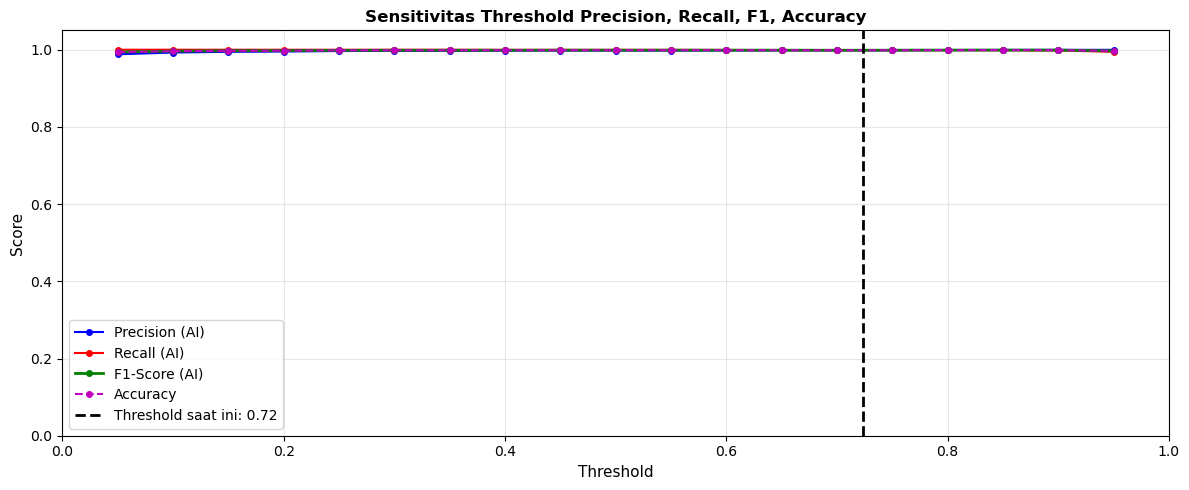

Plot disimpan ke: threshold_sensitivity.png

Threshold dengan F1 tertinggi: 0.80
  Precision : 0.9990
  Recall    : 0.9987
  F1-Score  : 0.9988
  Accuracy  : 0.9988


In [23]:
# -------------------------------------------------------
# Threshold Sensitivity Plot
# -------------------------------------------------------
thresholds_to_test = np.arange(0.05, 0.96, 0.05)
precisions, recalls, f1s, accs = [], [], [], []

for t in thresholds_to_test:
    y_pred_t = (y_pred_probs >= t).astype(int)
    tp = int(((y_pred_t == 1) & (y_test == 1)).sum())
    fp = int(((y_pred_t == 1) & (y_test == 0)).sum())
    fn = int(((y_pred_t == 0) & (y_test == 1)).sum())
    tn = int(((y_pred_t == 0) & (y_test == 0)).sum())

    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)
    acc  = (tp + tn) / max(len(y_test), 1)

    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    accs.append(acc)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds_to_test, precisions, "b-o",  ms=4, label="Precision (AI)")
ax.plot(thresholds_to_test, recalls,    "r-o",  ms=4, label="Recall (AI)")
ax.plot(thresholds_to_test, f1s,        "g-o",  ms=4, label="F1-Score (AI)", linewidth=2)
ax.plot(thresholds_to_test, accs,       "m--o", ms=4, label="Accuracy")
ax.axvline(optimal_threshold, color="black", linestyle="--", linewidth=2,
           label=f"Threshold saat ini: {optimal_threshold:.2f}")
ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Sensitivitas Threshold Precision, Recall, F1, Accuracy", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_sensitivity.png", dpi=130, bbox_inches="tight")
plt.show()
print("Plot disimpan ke: threshold_sensitivity.png")

# Tampilkan tabel
best_f1_idx = int(np.argmax(f1s))
print(f"\nThreshold dengan F1 tertinggi: {thresholds_to_test[best_f1_idx]:.2f}")
print(f"  Precision : {precisions[best_f1_idx]:.4f}")
print(f"  Recall    : {recalls[best_f1_idx]:.4f}")
print(f"  F1-Score  : {f1s[best_f1_idx]:.4f}")
print(f"  Accuracy  : {accs[best_f1_idx]:.4f}")
